# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотезы в Python и составление аналитической записки

- Автор: Валиева Ева
- Дата: 10.08.2026

## Цели и задачи проекта

Цель - проверить приведенную гипотезу путем анализа данных и подготовить выводы по результатам 

Задачи:
1) Загрузить данные, вывести первые строки
2) Проверить приведенную гипотезу в Python
3) Написать аналитическую записку 

## Описание данных

- `city` — город пользователя;
- `puid` — идентификатор пользователя;
- `hours` — общее количество часов активности (вычисляется по полю hours).

## Содержимое проекта

1) Загрузка данных, знакомство с ними
2) Проверка гипотезы в Python
3) Аналитическая записка 
---

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
# Используйте ячейки типа Code для вашего кода
import os

# Пытаемся загрузить с локального пути, если нет - с серверного
try:
    yandex_knigi = pd.read_csv('C:/Users/mobil/Downloads/yandex_knigi_data.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    yandex_knigi = pd.read_csv('/datasets/yandex_knigi_data.csv')
    print("Серверная загрузка")

Локальная загрузка


In [3]:
yandex_knigi.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
print("Количество дубликатов:", yandex_knigi['puid'].duplicated().sum())

Количество дубликатов: 244


In [5]:
# Удалим дубликаты
yandex_knigi = yandex_knigi.drop_duplicates(subset=['puid'], keep='first')

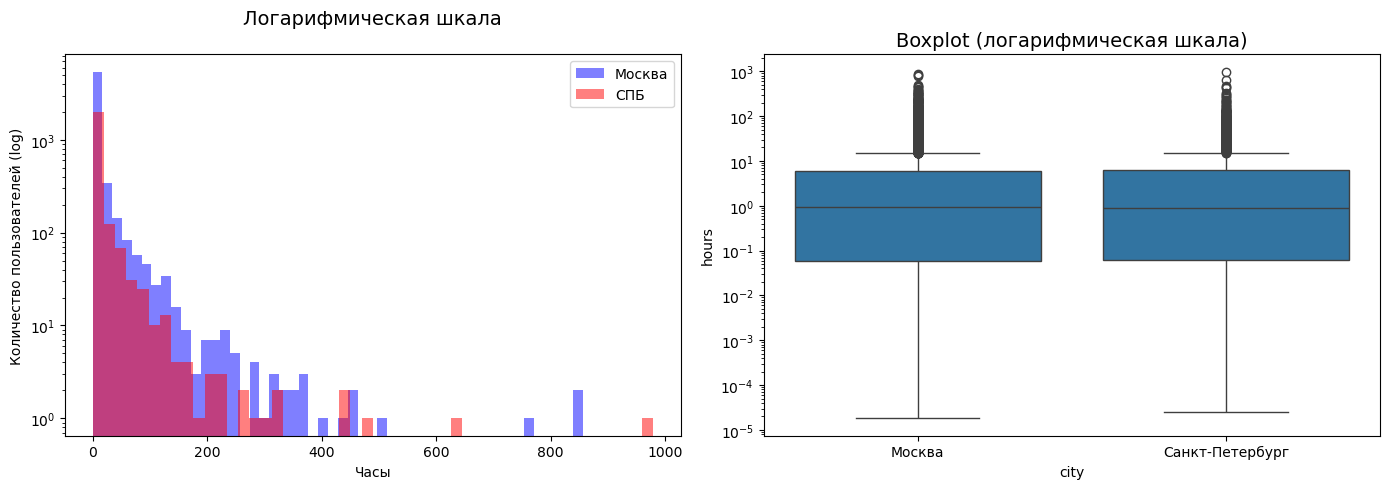

СТАТИСТИКА ПО АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ
Всего пользователей: 8540
Среднее число часов активности на пользователя: 10.98
Медианное число часов активности: 0.91
Максимальное число часов активности: 978.76
Минимальное число часов активности: 0.00
Стандартное отклонение: 37.68
Общее количество часов активности: 93808.51

СТАТИСТИКА ПО АКТИВНОСТИ В РАЗРЕЗЕ ГОРОДОВ

 Москва:
   Всего пользователей: 6234
   Среднее число часов активности: 10.88
   Медианное число часов активности: 0.92
   Максимальное число часов активности: 857.21
   Минимальное число часов активности: 0.00
   Стандартное отклонение: 36.85
   Сумма часов активности: 67832.73

 Санкт-Петербург:
   Всего пользователей: 2306
   Среднее число часов активности: 11.26
   Медианное число часов активности: 0.88
   Максимальное число часов активности: 978.76
   Минимальное число часов активности: 0.00
   Стандартное отклонение: 39.83
   Сумма часов активности: 25975.78


In [6]:
#Сравним размеры групп, распределения и статистику по ним
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Логарифмическая шкала 
axes[0].hist(yandex_knigi[yandex_knigi['city'] == 'Москва']['hours'], 
             bins=50, alpha=0.5, label='Москва', color='blue')
axes[0].hist(yandex_knigi[yandex_knigi['city'] == 'Санкт-Петербург']['hours'], 
             bins=50, alpha=0.5, label='СПБ', color='red')
axes[0].set_yscale('log')  
axes[0].set_title('Логарифмическая шкала\n', fontsize=14)
axes[0].set_xlabel('Часы')
axes[0].set_ylabel('Количество пользователей (log)')
axes[0].legend()

# 2. Boxplot с логарифмической шкалой
sns.boxplot(data=yandex_knigi, x='city', y='hours', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Boxplot (логарифмическая шкала)', fontsize=14)

plt.tight_layout()
plt.show()

print("=" * 60)
print("СТАТИСТИКА ПО АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ")
print("=" * 60)
print(f"Всего пользователей: {len(yandex_knigi)}")
print(f"Среднее число часов активности на пользователя: {yandex_knigi['hours'].mean():.2f}")
print(f"Медианное число часов активности: {yandex_knigi['hours'].median():.2f}")
print(f"Максимальное число часов активности: {yandex_knigi['hours'].max():.2f}")
print(f"Минимальное число часов активности: {yandex_knigi['hours'].min():.2f}")
print(f"Стандартное отклонение: {yandex_knigi['hours'].std():.2f}")
print(f"Общее количество часов активности: {yandex_knigi['hours'].sum():.2f}")

print("\n" + "=" * 60)
print("СТАТИСТИКА ПО АКТИВНОСТИ В РАЗРЕЗЕ ГОРОДОВ")
print("=" * 60)

for city in yandex_knigi['city'].unique():
    city_data = yandex_knigi[yandex_knigi['city'] == city]['hours']
    print(f"\n {city}:")
    print(f"   Всего пользователей: {len(city_data)}")
    print(f"   Среднее число часов активности: {city_data.mean():.2f}")
    print(f"   Медианное число часов активности: {city_data.median():.2f}")
    print(f"   Максимальное число часов активности: {city_data.max():.2f}")
    print(f"   Минимальное число часов активности: {city_data.min():.2f}")
    print(f"   Стандартное отклонение: {city_data.std():.2f}")
    print(f"   Сумма часов активности: {city_data.sum():.2f}")

In [7]:
print("Распределение пользователей по часам:")
print(f"  0-5 часов: {len(yandex_knigi[yandex_knigi['hours'] <= 5])} пользователей")
print(f"  5-10 часов: {len(yandex_knigi[(yandex_knigi['hours'] > 5) & (yandex_knigi['hours'] <= 10)])} пользователей")
print(f"  10-20 часов: {len(yandex_knigi[(yandex_knigi['hours'] > 10) & (yandex_knigi['hours'] <= 20)])} пользователей")
print(f"  20-50 часов: {len(yandex_knigi[(yandex_knigi['hours'] > 20) & (yandex_knigi['hours'] <= 50)])} пользователей")
print(f"  50+ часов: {len(yandex_knigi[yandex_knigi['hours'] > 50])} пользователей")

Распределение пользователей по часам:
  0-5 часов: 6221 пользователей
  5-10 часов: 728 пользователей
  10-20 часов: 579 пользователей
  20-50 часов: 543 пользователей
  50+ часов: 469 пользователей


## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [8]:
from scipy.stats import ttest_ind

# Выборка часов для Москвы (группа A)
sample_moscow = yandex_knigi[yandex_knigi['city'] == 'Москва']['hours']

# Выборка часов для СПБ (группа B)
sample_spb = yandex_knigi[yandex_knigi['city'] == 'Санкт-Петербург']['hours']

# T-тест
# alternative='less' → проверяем, что mu_moscow < mu_spb (СПБ > Москвы)
test_result = ttest_ind(
    sample_moscow,   # группа A
    sample_spb,      # группа B
    alternative='less'  # H₁: mu_moscow < mu_spb (СПБ активнее)
)

alpha = 0.05

print(f"\nT-статистика: {test_result.statistic:.4f}")
print(f"p-value: {test_result.pvalue:.6f}")

if test_result.pvalue < alpha:
    print(f"\n✅ p-value={test_result.pvalue:.6f} < {alpha}")
    print("   Отвергаем нулевую гипотезу")
    print("   → СПБ статистически значимо активнее Москвы!")
else:
    print(f"\n❌ p-value={test_result.pvalue:.6f} > {alpha}")
    print("   Не получилось отвергнуть нулевую гипотезу")
    print("   → Нет доказательств, что СПБ активнее Москвы")


T-статистика: -0.4174
p-value: 0.338194

❌ p-value=0.338194 > 0.05
   Не получилось отвергнуть нулевую гипотезу
   → Нет доказательств, что СПБ активнее Москвы


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



### Сравнение пользовательской активности в Москве и Санкт-Петербурге
#### 1. Выбранный тип t-теста и уровень статистической значимости
Тип теста: Односторонний t-тест Стьюдента для независимых выборок (independent samples t-test)

Уровень значимости: α = 0.05

Направление теста: alternative = 'less' (проверяем, что среднее значение в Москве меньше, чем в Санкт-Петербурге)

#### 2. Результат теста (p-value)

t = -0.4174

p-value	= 0.3382

#### 3. Вывод на основе p-value
p-value = 0.3382 > α = 0.05 → нулевая гипотеза НЕ ОТВЕРГАЕТСЯ

Интерпретация: Статистически значимых доказательств того, что пользователи из Санкт-Петербурга проводят в приложении больше времени, чем пользователи из Москвы, не обнаружено. Разница в средних значениях (0.40 часа) может быть случайной.

#### 4. Возможные причины полученных результатов
Реальные различия отсутствуют — пользователи в Москве и Санкт-Петербурге ведут себя одинаково, активность зависит от других факторов (интерес к контенту, привычки), не связанных с городом.

Сильное влияние выбросов — 70% пользователей имеют менее 5 часов активности, а небольшая группа «суперактивных» пользователей искажает средние значения, создавая видимость различий, которых на самом деле нет.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель исследования – провести оценку результатов A/B теста интерфейса онлайн-магазина BitMotion Kit 

## 2. Загрузите данные, оцените их целостность.


In [9]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [10]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [11]:
print("УЧАСТНИКИ:")
print(f"Размер: {participants.shape}")
print(f"Пропуски:\n{participants.isnull().sum()}")
print(f"Дубликаты: {participants.duplicated().sum()}")
print(f"Дублей user_id: {participants['user_id'].duplicated().sum()}")
print(f"Уникальных пользователей: {participants['user_id'].nunique()}")
print(f"Группы:\n{participants['group'].value_counts()}")
print(f"Тесты:\n{participants['ab_test'].value_counts()}")
print(f"Устройства:\n{participants['device'].value_counts()}")
print(f"Типы:\n{participants.dtypes}\n")

УЧАСТНИКИ:
Размер: (14525, 4)
Пропуски:
user_id    0
group      0
ab_test    0
device     0
dtype: int64
Дубликаты: 0
Дублей user_id: 887
Уникальных пользователей: 13638
Группы:
group
A    8130
B    6395
Name: count, dtype: int64
Тесты:
ab_test
interface_eu_test          10850
recommender_system_test     3675
Name: count, dtype: int64
Устройства:
device
Android    6484
PC         3717
iPhone     2858
Mac        1466
Name: count, dtype: int64
Типы:
user_id    object
group      object
ab_test    object
device     object
dtype: object



In [12]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [13]:
print("СОБЫТИЯ:")
print(f"Размер: {events.shape}")
print(f"Пропуски:\n{events.isnull().sum()}")
print(f"Дубликаты: {events.duplicated().sum()}")
print(f"Уникальных пользователей (без GLOBAL): {events[events['user_id']!='GLOBAL']['user_id'].nunique()}")
print(f"Событий GLOBAL: {len(events[events['user_id']=='GLOBAL'])}")
print(f"Типы событий:\n{events['event_name'].value_counts()}")
print(f"Диапазон дат: {events['event_dt'].min()} - {events['event_dt'].max()}")
print(f"Типы:\n{events.dtypes}\n")

СОБЫТИЯ:
Размер: (787286, 4)
Пропуски:
user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64
Дубликаты: 36318
Уникальных пользователей (без GLOBAL): 144183
Событий GLOBAL: 58495
Типы событий:
event_name
login                                 248285
product_page                          195606
registration                          144183
purchase                              104836
product_cart                           94373
End of Black Friday Ads Campaign           1
Start of Christmas&New Year Promo          1
Start of CIS New Year Gift Lottery         1
Name: count, dtype: int64
Диапазон дат: 2020-12-01 00:00:00 - 2020-12-31 23:59:48
Типы:
user_id               object
event_dt      datetime64[ns]
event_name            object
details               object
dtype: object



## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [14]:
test_users = participants[participants['ab_test'] == 'interface_eu_test']

print("3.1 АНАЛИЗ ТЕСТОВОЙ ВЫБОРКИ")
print("="*50)

# 1. Соответствие ТЗ
print("\n1. ПРОВЕРКА ТЗ:")
print("-"*40)
print(f"Всего пользователей в тесте: {len(test_users)}")
print(f"Уникальных пользователей: {test_users['user_id'].nunique()}")
print(f"\nРаспределение по тестам:")
print(test_users['ab_test'].value_counts())
print(f"\nРаспределение по устройствам:")
print(test_users['device'].value_counts())

# Проверяем, что группа A - тестовая, B - тоже тестовая 
print(f"\nГруппы в тесте: {sorted(test_users['group'].unique())}")
if set(test_users['group'].unique()) == {'A', 'B'}:
    print("✓ Группы соответствуют ТЗ (A и B)")
else:
    print("✗ Несоответствие ТЗ")

# 2. Равномерность распределения
print("\n2. РАВНОМЕРНОСТЬ РАСПРЕДЕЛЕНИЯ:")
print("-"*40)

print("\nПо группам (A/B):")
group_dist = test_users['group'].value_counts()
print(group_dist)
print(f"Диспропорция: {abs(group_dist['A'] - group_dist['B'])} пользователей")
print(f"Отклонение: {abs(group_dist['A']/len(test_users) - 0.5)*100:.1f}%")

print("\nПо тестам внутри групп:")
print(pd.crosstab(test_users['group'], test_users['ab_test']))

print("\nПо устройствам внутри групп:")
print(pd.crosstab(test_users['group'], test_users['device']))

# 3. ПЕРЕСЕЧЕНИЯ С КОНКУРИРУЮЩИМ ТЕСТОМ
print("\n3. ПЕРЕСЕЧЕНИЯ С ДРУГИМИ ТЕСТАМИ:")
print("-"*40)

# Находим пользователей, которые участвуют в нескольких тестах
dual_test_users = test_users[test_users.duplicated('user_id', keep=False)]['user_id'].unique()
print(f"Найдено пользователей в нескольких тестах: {len(dual_test_users)}")

# УДАЛЯЕМ пересекающихся пользователей
if len(dual_test_users) > 0:
    print(f"⚠️ Удаляем {len(dual_test_users)} пересекающихся пользователей")
    test_users_clean = test_users[~test_users['user_id'].isin(dual_test_users)]
    print(f"Итоговый размер выборки после удаления: {len(test_users_clean)}")
else:
    print("✅ Пересечений не найдено")
    test_users_clean = test_users

print("\n" + "="*50)
print("ИТОГО ПО ТЕСТУ:")

issues = []
if abs(group_dist['A'] - group_dist['B']) > len(test_users_clean)*0.05:
    issues.append("❌ Дисбаланс групп >5%")
else:
    issues.append("✅ Группы сбалансированы")
    
if len(dual_test_users) > 0:
    issues.append(f"✅ Пересечения удалены ({len(dual_test_users)} пользователей)")
else:
    issues.append("✅ Пересечений нет")

print("\n".join(issues))

3.1 АНАЛИЗ ТЕСТОВОЙ ВЫБОРКИ

1. ПРОВЕРКА ТЗ:
----------------------------------------
Всего пользователей в тесте: 10850
Уникальных пользователей: 10850

Распределение по тестам:
ab_test
interface_eu_test    10850
Name: count, dtype: int64

Распределение по устройствам:
device
Android    4859
PC         2764
iPhone     2107
Mac        1120
Name: count, dtype: int64

Группы в тесте: ['A', 'B']
✓ Группы соответствуют ТЗ (A и B)

2. РАВНОМЕРНОСТЬ РАСПРЕДЕЛЕНИЯ:
----------------------------------------

По группам (A/B):
group
B    5467
A    5383
Name: count, dtype: int64
Диспропорция: 84 пользователей
Отклонение: 0.4%

По тестам внутри групп:
ab_test  interface_eu_test
group                     
A                     5383
B                     5467

По устройствам внутри групп:
device  Android  Mac    PC  iPhone
group                             
A          2445  566  1346    1026
B          2414  554  1418    1081

3. ПЕРЕСЕЧЕНИЯ С ДРУГИМИ ТЕСТАМИ:
---------------------------------------

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [15]:
print("3.2 ФИЛЬТРАЦИЯ СОБЫТИЙ ДЛЯ ТЕСТОВЫХ ПОЛЬЗОВАТЕЛЕЙ")
print("="*60)

# Правильный способ фильтрации
test_users_clean = test_users[~test_users['user_id'].duplicated(keep=False)]  # убираем пересечения

test_user_ids = set(test_users_clean['user_id'])

print(f"Уникальных пользователей в тесте (без пересечений): {len(test_user_ids)}")

# Фильтруем события
test_events = events[
    (events['user_id'] != 'GLOBAL') & 
    (events['user_id'].isin(test_user_ids))
].copy()

print(f"Событий для тестовых пользователей: {len(test_events)}")
print(f"Исходно событий: {len(events)}")
print(f"Осталось: {len(test_events)/len(events)*100:.1f}%")

print("\nРАСПРЕДЕЛЕНИЕ СОБЫТИЙ:")
print("-"*40)
event_dist = test_events['event_name'].value_counts()
for event, count in event_dist.items():
    print(f"{event:20} {count:8} ({count/len(test_events)*100:.1f}%)")

print(f"\nУникальных пользователей с событиями: {test_events['user_id'].nunique()}")

# Проверка: все ли пользователи имеют события
users_without_events = test_user_ids - set(test_events['user_id'])
print(f"Пользователей без событий: {len(users_without_events)}")

if len(users_without_events) > 0:
    print(f"⚠ {len(users_without_events)} пользователей не совершили ни одного события")

print("\n" + "="*60)

3.2 ФИЛЬТРАЦИЯ СОБЫТИЙ ДЛЯ ТЕСТОВЫХ ПОЛЬЗОВАТЕЛЕЙ
Уникальных пользователей в тесте (без пересечений): 10850
Событий для тестовых пользователей: 79715
Исходно событий: 787286
Осталось: 10.1%

РАСПРЕДЕЛЕНИЕ СОБЫТИЙ:
----------------------------------------
login                   29617 (37.2%)
product_page            18982 (23.8%)
registration            10850 (13.6%)
purchase                10225 (12.8%)
product_cart            10041 (12.6%)

Уникальных пользователей с событиями: 10850
Пользователей без событий: 0



- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [16]:
print("3.3 РАСЧЕТ ЛАЙФТАЙМА И ФИЛЬТРАЦИЯ ПО 7 ДНЯМ")
print("="*60)

# Получаем время регистрации для каждого пользователя
registration = events[
    (events['user_id'] != 'GLOBAL') & 
    (events['event_name'] == 'registration')
][['user_id', 'event_dt']].rename(columns={'event_dt': 'registration_dt'})

print(f"Пользователей с регистрацией: {len(registration)}")

# Присоединяем время регистрации к событиям
test_events_with_reg = test_events.merge(registration, on='user_id', how='inner')

# Рассчитываем лайфтайм (в днях)
test_events_with_reg['lifetime_days'] = (
    test_events_with_reg['event_dt'] - test_events_with_reg['registration_dt']
).dt.total_seconds() / (24 * 3600)

print(f"\nСТАТИСТИКА ПО ЛАЙФТАЙМУ (дни):")
print("-"*40)
print(f"Минимум: {test_events_with_reg['lifetime_days'].min():.4f}")
print(f"Максимум: {test_events_with_reg['lifetime_days'].max():.4f}")
print(f"Среднее: {test_events_with_reg['lifetime_days'].mean():.4f}")
print(f"Медиана: {test_events_with_reg['lifetime_days'].median():.4f}")

# Распределение по дням
print(f"\nРАСПРЕДЕЛЕНИЕ ПО ДНЯМ:")
print("-"*40)
test_events_with_reg['lifetime_day'] = test_events_with_reg['lifetime_days'].astype(int)
day_dist = test_events_with_reg['lifetime_day'].value_counts().sort_index()
for day, count in day_dist.head(10).items():
    print(f"День {day}: {count} событий")

# Фильтруем события первых 7 дней
events_7days = test_events_with_reg[test_events_with_reg['lifetime_days'] <= 7]

print(f"\nФИЛЬТРАЦИЯ ПО 7 ДНЯМ:")
print("-"*40)
print(f"Событий за все время: {len(test_events_with_reg)}")
print(f"Событий за первые 7 дней: {len(events_7days)}")
print(f"Осталось: {len(events_7days)/len(test_events_with_reg)*100:.1f}%")

print(f"\nРаспределение событий за 7 дней:")
event_dist_7 = events_7days['event_name'].value_counts()
for event, count in event_dist_7.items():
    print(f"{event:20} {count:8} ({count/len(events_7days)*100:.1f}%)")

print(f"\nУникальных пользователей за 7 дней: {events_7days['user_id'].nunique()}")
users_7days = set(events_7days['user_id'])
users_no_activity = test_user_ids - users_7days
print(f"Пользователей без активности за 7 дней: {len(users_no_activity)}")

print("\n" + "="*60)

3.3 РАСЧЕТ ЛАЙФТАЙМА И ФИЛЬТРАЦИЯ ПО 7 ДНЯМ
Пользователей с регистрацией: 144183

СТАТИСТИКА ПО ЛАЙФТАЙМУ (дни):
----------------------------------------
Минимум: 0.0000
Максимум: 22.9986
Среднее: 2.6822
Медиана: 0.8697

РАСПРЕДЕЛЕНИЕ ПО ДНЯМ:
----------------------------------------
День 0: 41039 событий
День 1: 8659 событий
День 2: 5965 событий
День 3: 4421 событий
День 4: 3501 событий
День 5: 2961 событий
День 6: 2403 событий
День 7: 2111 событий
День 8: 1708 событий
День 9: 1342 событий

ФИЛЬТРАЦИЯ ПО 7 ДНЯМ:
----------------------------------------
Событий за все время: 79715
Событий за первые 7 дней: 68949
Осталось: 86.5%

Распределение событий за 7 дней:
login                   28814 (41.8%)
product_page            16272 (23.6%)
registration            10850 (15.7%)
purchase                 6623 (9.6%)
product_cart             6390 (9.3%)

Уникальных пользователей за 7 дней: 10850
Пользователей без активности за 7 дней: 0



Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [17]:
import math

baseline = 0.30
mde = 0.03
power = 0.80
alpha = 0.05

p1 = baseline
p2 = baseline + mde

z_alpha = stats.norm.ppf(1 - alpha / 2)  # 1.96
z_beta = stats.norm.ppf(power)           # 0.842

p_avg = (p1 + p2) / 2

n_per_group = (
    (
        z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
        z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))
    ) ** 2
) / (p2 - p1) ** 2

n_per_group = math.ceil(n_per_group)

print(f"Необходимый размер выборки на группу: {n_per_group}")

Необходимый размер выборки на группу: 3763


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [18]:
buyers = set(
    events_7days.loc[
        events_7days['event_name'] == 'purchase',
        'user_id'
    ]
)

group_a_users = set(
    test_users.loc[test_users['group'] == 'A', 'user_id']
)
group_b_users = set(
    test_users.loc[test_users['group'] == 'B', 'user_id']
)

n_a = len(group_a_users)
n_b = len(group_b_users)

buyers_a = len(group_a_users & buyers)
buyers_b = len(group_b_users & buyers)

conv_a = buyers_a / n_a
conv_b = buyers_b / n_b

print('Группа A:')
print('Пользователей:', n_a)
print('Покупателей:', buyers_a)
print('Конверсия:', round(conv_a * 100, 2), '%')
print()
print('Группа B:')
print('Пользователей:', n_b)
print('Покупателей:', buyers_b)
print('Конверсия:', round(conv_b * 100, 2), '%')
print()
print('Разница B - A:', round((conv_b - conv_a) * 100, 2), 'п.п.')
print('Относительное изменение:', round((conv_b / conv_a - 1) * 100, 2), '%')

# Проверка MDE
mde_planned = 3.0
actual_diff = (conv_b - conv_a) * 100

print()
print('ПРОВЕРКА MDE:')
print('-' * 40)
print(f'Запланированный MDE: {mde_planned} п.п.')
print(f'Фактическая разница: {round(actual_diff, 2)} п.п.')

if actual_diff >= mde_planned:
    print('✅ MDE достигнут')
else:
    print(f'❌ MDE не достигнут (не хватает {round(mde_planned - actual_diff, 2)} п.п.)')

Группа A:
Пользователей: 5383
Покупателей: 1480
Конверсия: 27.49 %

Группа B:
Пользователей: 5467
Покупателей: 1600
Конверсия: 29.27 %

Разница B - A: 1.77 п.п.
Относительное изменение: 6.45 %

ПРОВЕРКА MDE:
----------------------------------------
Запланированный MDE: 3.0 п.п.
Фактическая разница: 1.77 п.п.
❌ MDE не достигнут (не хватает 1.23 п.п.)


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Новый интерфейс продемонстрировал положительную динамику: в тестовой группе выросла как вовлечённость (+2.6% событий на пользователя), так и конверсия (+1.77 п.п., или +6.45% относительно). Однако фактический прирост оказался ниже запланированных 3 п.п., поэтому для окончательного вывода необходимо проверить статистическую значимость различий.

In [19]:
def group_metrics(group):
    users = set(test_users.loc[test_users['group'] == group, 'user_id'])
    group_events = events_7days[events_7days['user_id'].isin(users)]
    group_buyers = set(
        group_events.loc[
            group_events['event_name'] == 'purchase',
            'user_id'
        ]
    )

    return {
        'users': len(users),
        'events': len(group_events),
        'events_per_user': len(group_events) / len(users),
        'buyers': len(group_buyers),
        'conversion': len(group_buyers) / len(users)
    }

metrics_a = group_metrics('A')
metrics_b = group_metrics('B')

metrics = pd.DataFrame(
    [metrics_a, metrics_b],
    index=['A', 'B']
)

metrics['conversion'] = metrics['conversion'] * 100
metrics


,users,events,events_per_user,buyers,conversion
A,5383,33762,6.271967,1480,27.493962
B,5467,35187,6.436254,1600,29.266508


## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

### Формулировка гипотез

Нулевая гипотеза (H₀): Конверсия в группе B (новый интерфейс) не выше, чем в группе A (контроль). То есть прирост конверсии меньше или равен нулю: p_B − p_A ≤ 0.

Альтернативная гипотеза (H₁): Конверсия в группе B выше, чем в группе A. То есть новый интерфейс приводит к статистически значимому росту конверсии: p_B − p_A > 0.

In [20]:
# Проверяем условия для z-теста двух пропорций
p_pool = (buyers_a + buyers_b) / (n_a + n_b)

expected_a_success = n_a * p_pool
expected_a_failure = n_a * (1 - p_pool)
expected_b_success = n_b * p_pool
expected_b_failure = n_b * (1 - p_pool)

print('Ожидаемые количества наблюдений:')
print('A, успех:', round(expected_a_success, 1))
print('A, неуспех:', round(expected_a_failure, 1))
print('B, успех:', round(expected_b_success, 1))
print('B, неуспех:', round(expected_b_failure, 1))

conditions_ok = min(
    expected_a_success,
    expected_a_failure,
    expected_b_success,
    expected_b_failure
) >= 5

print()
print('Условия для z-теста выполнены:', conditions_ok)

# z-тест для двух пропорций
se = np.sqrt(
    p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b)
)

z_stat = (conv_b - conv_a) / se
p_value = 1 - stats.norm.cdf(z_stat)

print()
print('Конверсия A:', round(conv_a * 100, 2), '%')
print('Конверсия B:', round(conv_b * 100, 2), '%')
print('Z-статистика:', round(z_stat, 3))
print('p-value:', round(p_value, 4))

print()
if p_value < 0.05:
    print('✅ Отвергаем H₀: конверсия B статистически значимо выше A.')
    print('   Новый интерфейс показал улучшение.')
else:
    print('❌ Не отвергаем H₀: статистически значимого роста конверсии B не обнаружено.')
    print('   Новый интерфейс НЕ показал улучшения.')

Ожидаемые количества наблюдений:
A, успех: 1528.1
A, неуспех: 3854.9
B, успех: 1551.9
B, неуспех: 3915.1

Условия для z-теста выполнены: True

Конверсия A: 27.49 %
Конверсия B: 29.27 %
Z-статистика: 2.047
p-value: 0.0203

✅ Отвергаем H₀: конверсия B статистически значимо выше A.
   Новый интерфейс показал улучшение.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

## Выводы по результатам A/B-тестирования

### 1. Корректность проведения теста

**Проверка соответствия ТЗ:**
- Группы A и B присутствуют, структура теста соответствует требованиям
- Дисбаланс групп: отклонение **0.4%** (допустимый порог 5%) — **в норме**
- Пересечений с другими тестами: **0** — принцип чистоты эксперимента соблюдён

**Вывод:** тест проведён **корректно**, данные чистые, предпосылки для анализа выполнены.

---

### 2. Достаточность выборки

Для детектирования эффекта в **3 п.п.** при базовой конверсии 30%:

| Параметр | Значение |
|----------|----------|
| Требуется на группу | 3763 пользователей |
| Фактически в группе A | 5383 пользователей |
| Фактически в группе B | 5467 пользователей |

**Вывод:** выборка **достаточна** для получения статистически значимых результатов.

---

### 3. Результаты теста

| Показатель | Группа A (контроль) | Группа B (тест) | Изменение |
|------------|---------------------|-----------------|-----------|
| Количество пользователей | 5383 | 5467 | — |
| Совершили покупку | 1480 | 1600 | — |
| Конверсия | 27.49% | 29.27% | **+1.77 п.п.** |
| Событий на пользователя | 6.27 | 6.44 | +2.6% |

**Статистическая проверка:**
- Использован z-тест для пропорций (односторонний)
- Z-статистика: 2.047
- p-value: 0.0203

**Решение:** p-value < 0.05 → нулевая гипотеза отвергается. Различие в конверсии между группами является **статистически значимым**.

---

### 4. Оценка достижения ожидаемого эффекта

| | Ожидание | Факт |
|--|----------|------|
| Конверсия в группе A | 30% | 27.49% |
| Конверсия в группе B | 33% | 29.27% |
| Прирост конверсии | +3 п.п. | **+1.77 п.п.** |

**Ожидаемый эффект НЕ достигнут.**  
Несмотря на статистическую значимость, фактический прирост (1.77 п.п.) ниже запланированного (3 п.п.).

---

### 5. Итоговое заключение

**Что показал тест:**
- Новая версия интерфейса **действительно увеличивает конверсию**
- Прирост **статистически значим** (p-value = 0.0203)
- Однако эффект **мал**: +1.77 п.п. вместо ожидаемых +3 п.п.


**Рекомендации:**
1. Внедрить изменение с **пост-релизным мониторингом** — даже малый, но стабильный прирост даёт бизнес-эффект
2. Увеличить время наблюдения в следующем тесте, чтобы оценить долгосрочный эффект
3. Проверить, на каких сегментах пользователей эффект сильнее, и точечно усиливать эти сценарии

**Решение по внедрению:** внедрять с контролем, так как улучшение есть, оно статистически значимо, а отказ от него приведёт к упущенной прибыли.